## 随机森林

In [1]:
%matplotlib inline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_wine

In [2]:
wine = load_wine()

1. 实例化
2. 将训练集代入模型训练，使用接口`fit`
3. 将测试集导入模型，获取希望的结果`score`

In [3]:
from sklearn.model_selection import train_test_split

In [7]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(wine.data, wine.target, train_size=0.7)

In [8]:
print(Xtrain.shape, Xtest.shape)

(124, 13) (54, 13)


In [10]:
clf = DecisionTreeClassifier(random_state=42)
rfc = RandomForestClassifier(random_state=42)

clf.fit(Xtrain, Ytrain)
rfc.fit(Xtrain, Ytrain)

score_c = clf.score(Xtest, Ytest)
score_r = rfc.score(Xtest, Ytest)

print(f"Decision Tree:{score_c}")
print(f"Random Forest:{score_r}")

Decision Tree:0.8148148148148148
Random Forest:0.9629629629629629


In [11]:
# 交叉验证
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

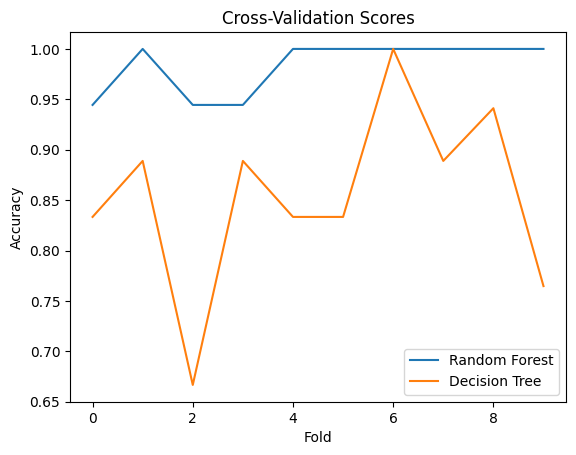

In [12]:
rfc = RandomForestClassifier(n_estimators=25)
rfc_s = cross_val_score(rfc, wine.data, wine.target, cv=10)

clf = DecisionTreeClassifier()
clf_s = cross_val_score(clf, wine.data, wine.target, cv=10)

plt.plot(rfc_s, label="Random Forest")
plt.plot(clf_s, label="Decision Tree")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Scores")
plt.legend()
plt.show()


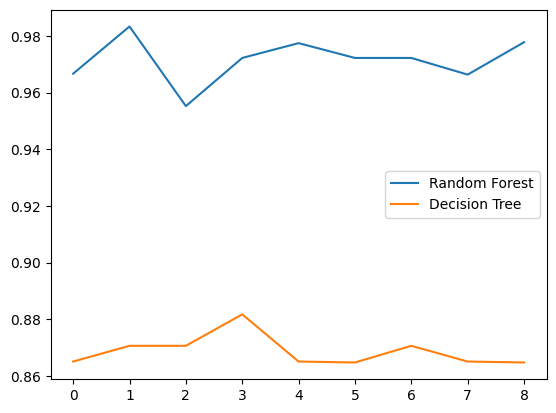

In [17]:
clf_l = []
rfc_l = []

for i in range(1, 10):
    rfc = RandomForestClassifier(n_estimators=25)
    rfc_s = cross_val_score(rfc, wine.data, wine.target, cv=10).mean()
    
    clf = DecisionTreeClassifier()
    clf_s = cross_val_score(clf, wine.data, wine.target, cv=10).mean()
    
    rfc_l.append(rfc_s)
    clf_l.append(clf_s)
    
    
plt.plot( rfc_l, label="Random Forest")
plt.plot( clf_l, label="Decision Tree")
plt.legend()
plt.show()

0.9888888888888889 18


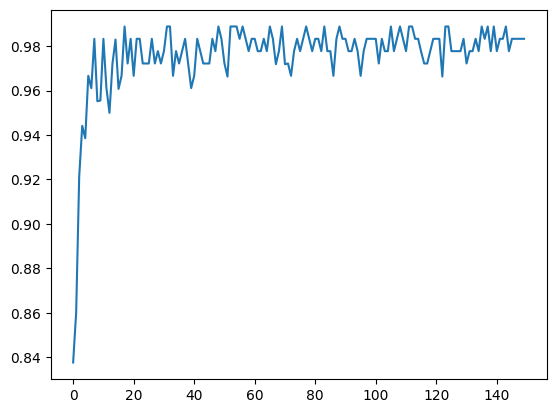

In [18]:
superpa = []

for i in range(150):
    rfc = RandomForestClassifier(n_estimators=i+1, n_jobs=-1)
    rfc_s = cross_val_score(rfc, wine.data, wine.target, cv=10).mean()
    
    superpa.append(rfc_s)
    
print(max(superpa), superpa.index(max(superpa))+1)

plt.plot(superpa, label="Random Forest")
plt.show()

In [30]:
# random_state的设置
rfc= RandomForestClassifier(n_estimators=10, random_state=42)

rfc = rfc.fit(Xtrain, Ytrain)
for i in range(10):
    
    print(rfc.estimators_[i].random_state)

1608637542
1273642419
1935803228
787846414
996406378
1201263687
423734972
415968276
670094950
1914837113


In [31]:
rfc_1 = RandomForestClassifier(n_estimators=25, oob_score=True)
rfc_1 = rfc_1.fit(Xtrain, Ytrain)

In [33]:
# 袋外数据的测试结果
rfc_1.oob_score_

0.9435483870967742